In [ ]:
!pip install torchmetrics

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch import autograd
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.utils import make_grid

from torchmetrics import Accuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from PIL import Image
from scipy.linalg import sqrtm
from tqdm.auto import tqdm, trange

In [ ]:
# torch.manual_seed(2007)

Считаем данные и посмотрим на картинки

In [ ]:
fashion_df = pd.read_csv('fashionmnist/fashion-mnist_train.csv')

In [ ]:
test_df = pd.read_csv("fashionmnist/fashion-mnist_test.csv")

In [ ]:
X_train, y_train = fashion_df.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28), fashion_df.label.values

In [ ]:
X_test, y_test = test_df.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28), test_df.label.values

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
fashion_df.shape

(60000, 785)

In [ ]:
fashion_df[["label"]].value_counts()

,count
label,
0,6000
1,6000
2,6000
3,6000
4,6000
5,6000
6,6000
7,6000
8,6000


In [ ]:
namelist = [
    'T-Shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

name_to_id = dict()
id_to_name = dict()

for id, name in enumerate(namelist):
  name_to_id[name] = id
  id_to_name[id] = name
id_to_name, name_to_id

({0: 'T-Shirt',
  1: 'Trouser',
  2: 'Pullover',
  3: 'Dress',
  4: 'Coat',
  5: 'Sandal',
  6: 'Shirt',
  7: 'Sneaker',
  8: 'Bag',
  9: 'Ankle boot'},
 {'T-Shirt': 0,
  'Trouser': 1,
  'Pullover': 2,
  'Dress': 3,
  'Coat': 4,
  'Sandal': 5,
  'Shirt': 6,
  'Sneaker': 7,
  'Bag': 8,
  'Ankle boot': 9})

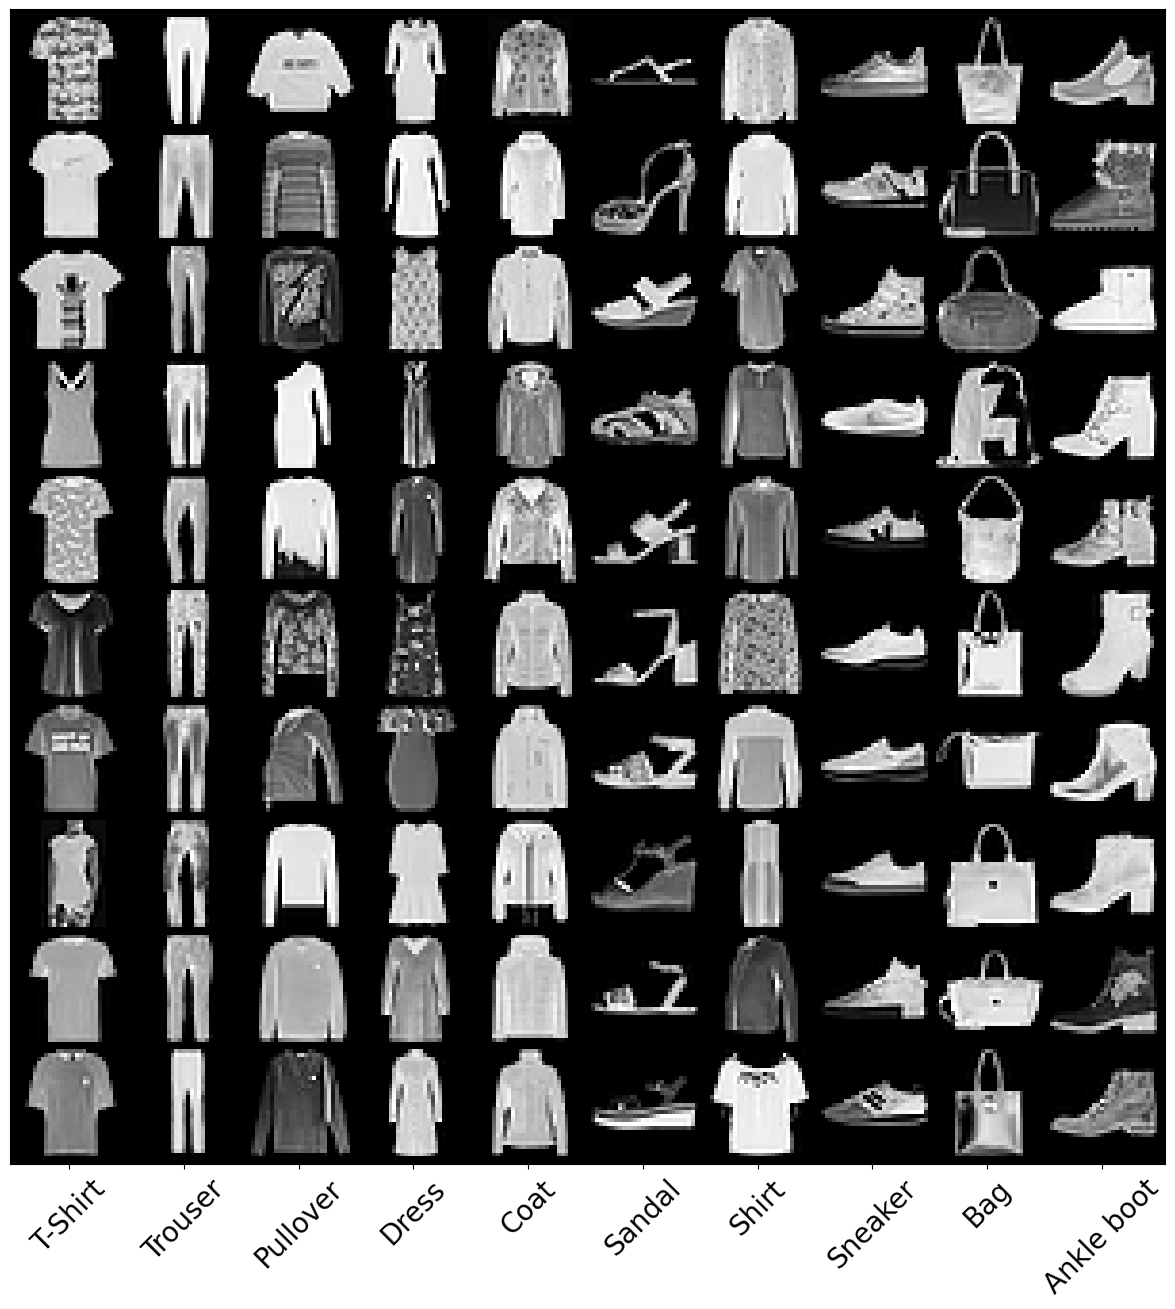

In [ ]:
images = fashion_df.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28)
labels = fashion_df[["label"]]
img_for_labels = [0] * 100
for i in range(10):
  img_label = labels[labels['label'] == i]
  index_list = list(img_label.index)[:10]
  for m, j in enumerate(index_list):
    img_for_labels[10 * m + i] = images[j]


img_for_labels = np.array(img_for_labels)
img_for_labels = torch.Tensor(img_for_labels).unsqueeze(1)
grid = make_grid(img_for_labels, nrow=10, normalize=True).permute(1, 2, 0).numpy()
fig, ax = plt.subplots(figsize=(15,15))
ax.imshow(grid)
_ = plt.yticks([])
_ = plt.xticks(np.arange(15, 300, 30), ['T-Shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], rotation=45, fontsize=20)

#Реализация Pytorch pipeline
###Создадим Dataset и Dataloader

In [ ]:
class FashionMNIST(Dataset):
  def __init__(self, X, y, transform=None):
    super().__init__()
    self.transform = transform
    self.labels = y
    self.images = X


  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    label = self.labels[idx]
    img = Image.fromarray(self  .images[idx])

    if self.transform:
      img = self.transform(img)
    return img, label

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = FashionMNIST(X_train, y_train, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = FashionMNIST(X_test, y_test, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

###Реализация архитектуры C-GAN

Для начало используем обычную MLP based архитектуру

In [ ]:
class SimpleDiscriminator(nn.Module):
    def __init__(self):
      super().__init__()

      self.label_emb = nn.Embedding(10, 10)

      self.model = nn.Sequential(
          nn.Linear(794, 1024),
          nn.LeakyReLU(0.2, inplace=True),
          nn.Dropout(0.3),

          nn.Linear(1024, 512),
          nn.LeakyReLU(0.2, inplace=True),
          nn.Dropout(0.3),

          nn.Linear(512, 256),
          nn.LeakyReLU(0.2, inplace=True),
          nn.Dropout(0.3),

          nn.Linear(256, 1),
          nn.Sigmoid()
      )

    def forward(self, x, labels):
      x = x.view(x.size(0), 784)
      c = self.label_emb(labels)
      x = torch.cat([x, c], 1)
      out = self.model(x)
      return out.squeeze()

In [ ]:
class SimpleGenerator(nn.Module):
    def __init__(self):
      super().__init__()

      self.label_emb = nn.Embedding(10, 10)

      self.model = nn.Sequential(
          nn.Linear(110, 256),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(256, 512),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(512, 1024),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(1024, 784),
          nn.Tanh()
      )

    def forward(self, z, labels):
      z = z.view(z.size(0), 100)
      c = self.label_emb(labels)
      x = torch.cat([z, c], 1)
      out = self.model(x)
      return out.view(x.size(0), 28, 28)

In [ ]:
generator = SimpleGenerator()
discriminator = SimpleDiscriminator()

criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)

In [ ]:
# generator.load_state_dict(torch.load("generator.pth"))
# discriminator.load_state_dict(torch.load("discriminator.pth"))

<All keys matched successfully>

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
def generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion, device='cpu'):
  g_optimizer.zero_grad()

  z = torch.randn(batch_size, 100).to(device)
  fake_labels = torch.LongTensor(np.random.randint(0, 10, batch_size)).to(device)
  fake_images = generator(z, fake_labels)

  validity = discriminator(fake_images, fake_labels)

  g_loss = criterion(validity, torch.ones(batch_size).to(device))
  g_loss.backward()
  g_optimizer.step()
  return g_loss.item()

In [ ]:
def discriminator_train_step(batch_size, discriminator, generator, d_optimizer, criterion, real_images, labels, device='cpu'):
  d_optimizer.zero_grad()


  real_validity = discriminator(real_images, labels)
  real_loss = criterion(real_validity, torch.ones(batch_size).to(device))


  z = torch.randn(batch_size, 100).to(device)
  fake_labels = torch.LongTensor(np.random.randint(0, 10, batch_size)).to(device)
  fake_images = generator(z, fake_labels)
  fake_validity = discriminator(fake_images, fake_labels)
  fake_loss = criterion(fake_validity, torch.zeros(batch_size).to(device))

  d_loss = real_loss + fake_loss
  d_loss.backward()
  d_optimizer.step()
  return d_loss.item()

In [ ]:
generator.to(device)
discriminator.to(device)

SimpleDiscriminator(
  (label_emb): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=794, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

###Training Loop

Epoch 1/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 2.732600212097168, d_loss: 0.6015431880950928


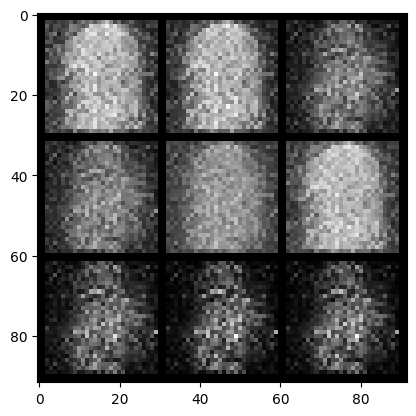

Epoch 2/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 4.557867527008057, d_loss: 0.3898470103740692


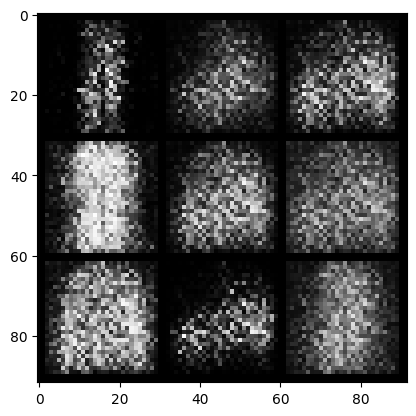

Epoch 3/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 2.904810667037964, d_loss: 0.3584612011909485


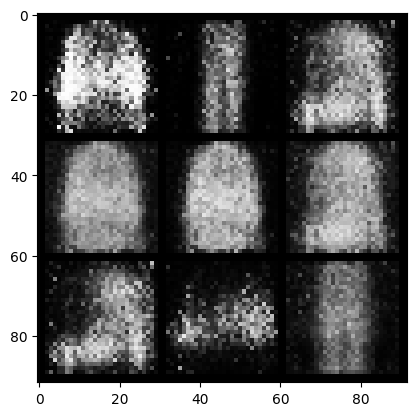

Epoch 4/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 2.4556078910827637, d_loss: 0.9091628789901733


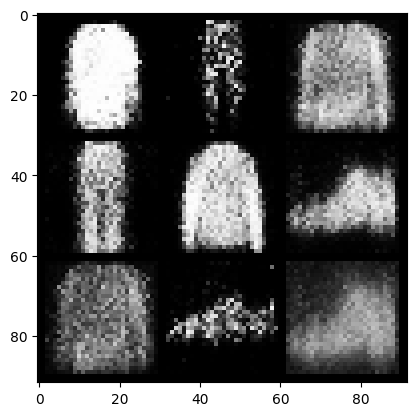

Epoch 5/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 2.3233776092529297, d_loss: 0.7989249229431152


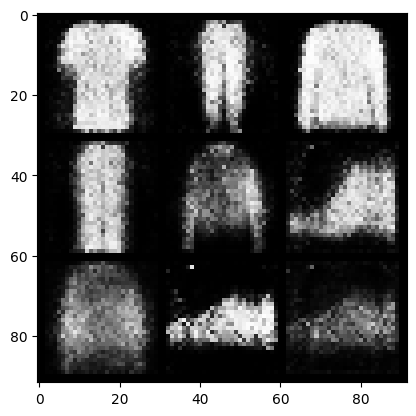

Epoch 6/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 2.3762757778167725, d_loss: 0.7331445813179016


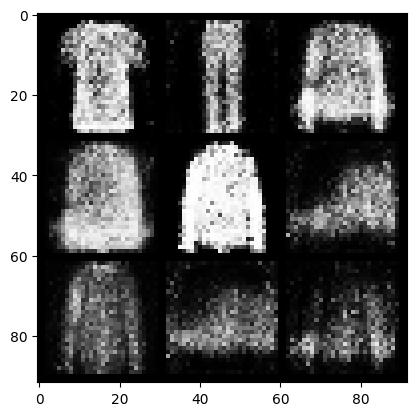

Epoch 7/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 2.2369186878204346, d_loss: 0.7746753096580505


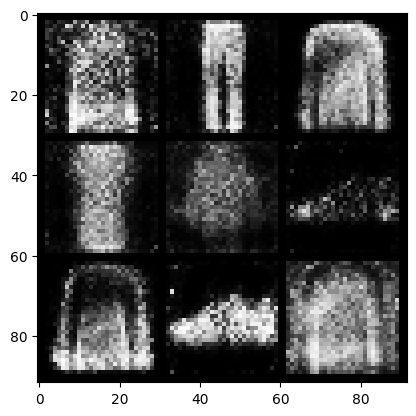

Epoch 8/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.9855635166168213, d_loss: 0.5222837924957275


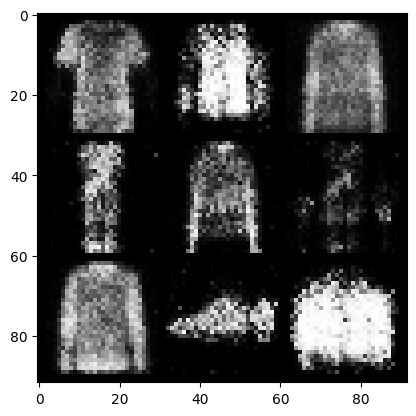

Epoch 9/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.593124508857727, d_loss: 0.9104233980178833


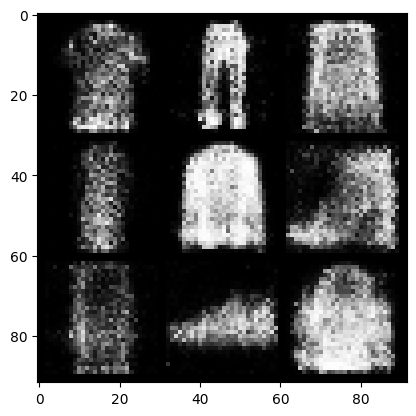

Epoch 10/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.9243634939193726, d_loss: 0.8464416265487671


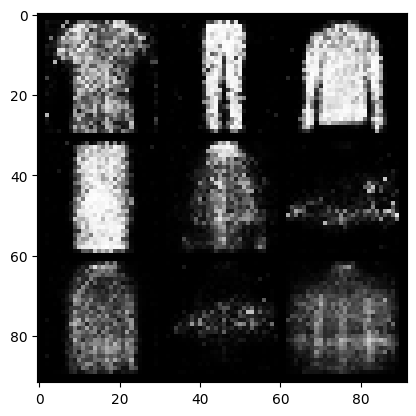

Epoch 11/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.4000325202941895, d_loss: 0.8677157163619995


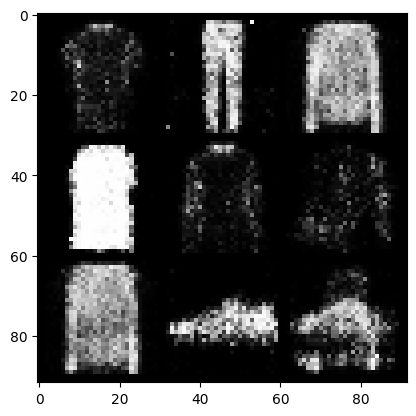

Epoch 12/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.5270681381225586, d_loss: 0.5728672742843628


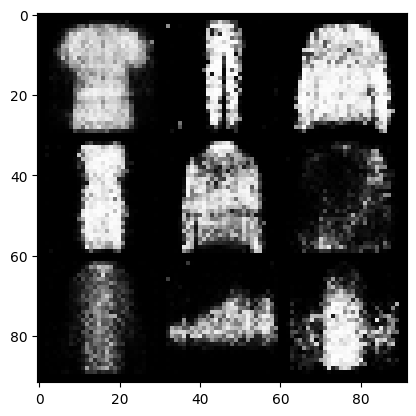

Epoch 13/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.407885193824768, d_loss: 1.1042463779449463


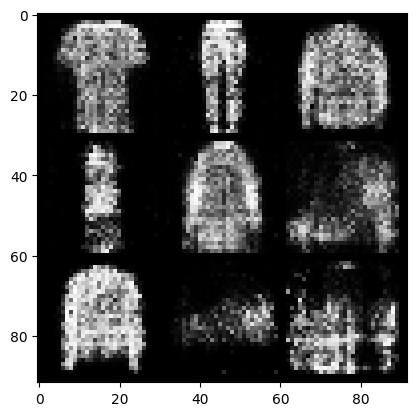

Epoch 14/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.3455615043640137, d_loss: 1.1204931735992432


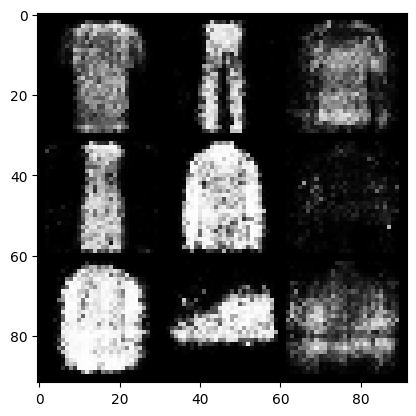

Epoch 15/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.5423715114593506, d_loss: 0.9964337348937988


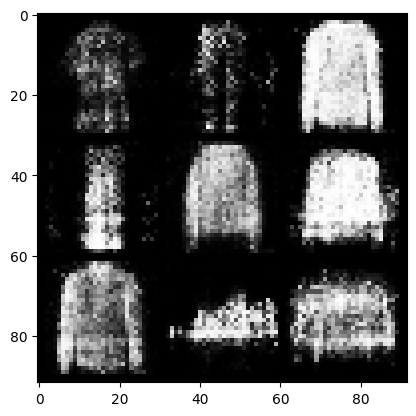

Epoch 16/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.3850147724151611, d_loss: 0.810594916343689


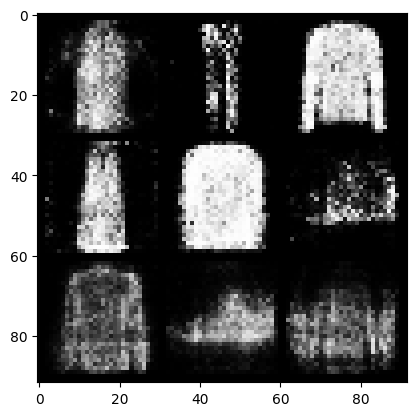

Epoch 17/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.549714207649231, d_loss: 1.216041922569275


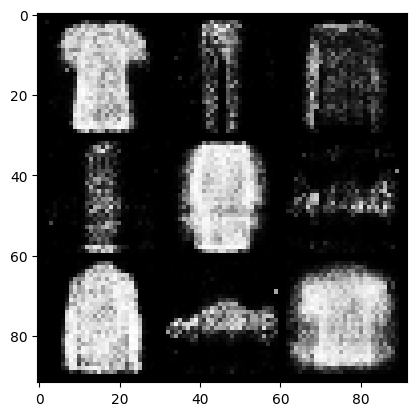

Epoch 18/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.5360465049743652, d_loss: 0.784990131855011


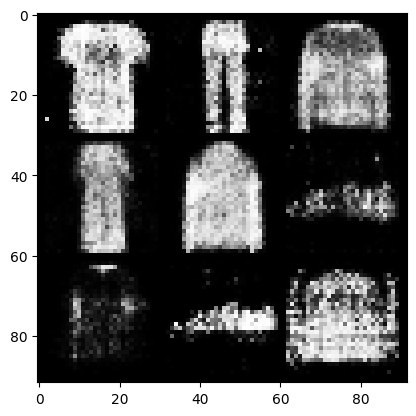

Epoch 19/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.5312833786010742, d_loss: 1.123478651046753


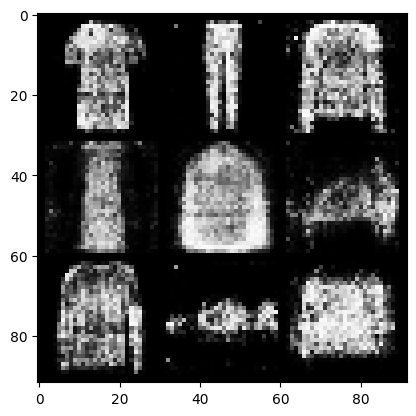

Epoch 20/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.2802854776382446, d_loss: 0.8113701939582825


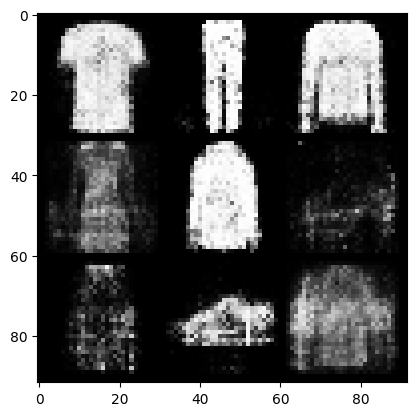

Epoch 21/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.226764440536499, d_loss: 1.1084586381912231


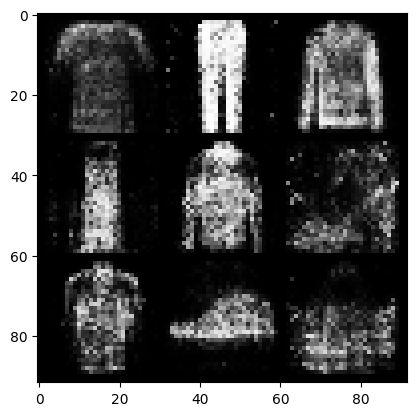

Epoch 22/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.3020577430725098, d_loss: 1.0115536451339722


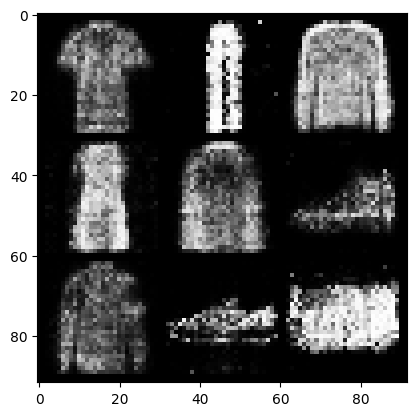

Epoch 23/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.322286605834961, d_loss: 0.9850900173187256


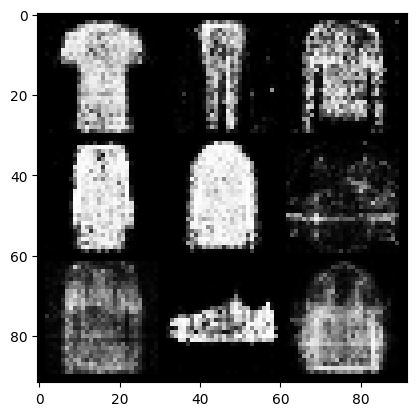

Epoch 24/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.187111258506775, d_loss: 0.9312152862548828


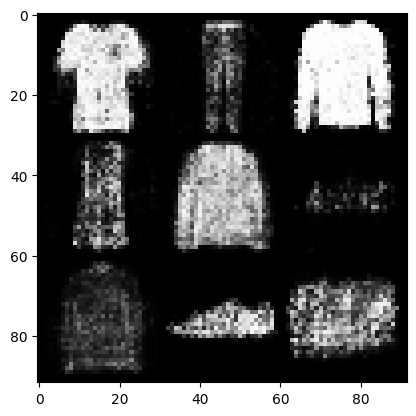

Epoch 25/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.223355770111084, d_loss: 0.9878472089767456


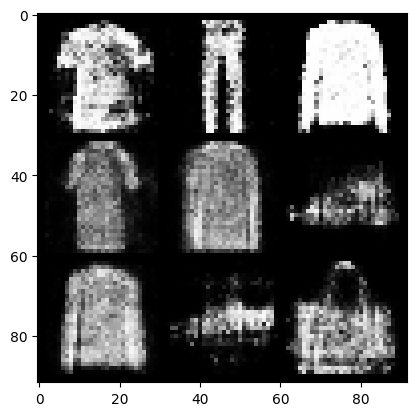

Epoch 26/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.2297565937042236, d_loss: 1.208183765411377


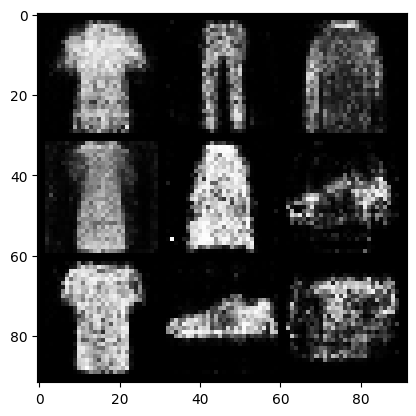

Epoch 27/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.0652251243591309, d_loss: 1.3188139200210571


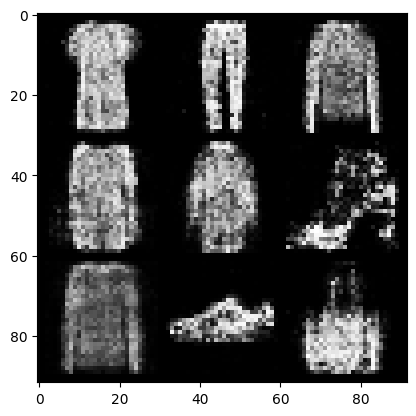

Epoch 28/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.3837199211120605, d_loss: 1.3256803750991821


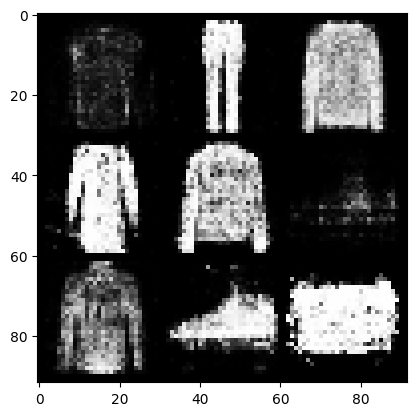

Epoch 29/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 0.9610146880149841, d_loss: 1.3619275093078613


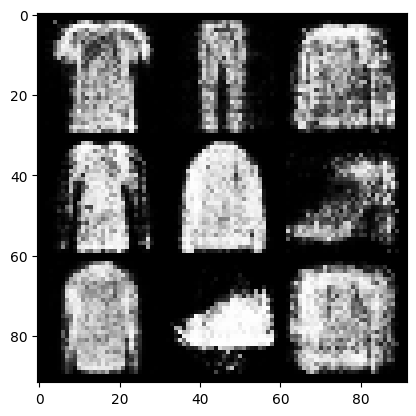

Epoch 30/30


  0%|          | 0/938 [00:00<?, ?it/s]

g_loss: 1.172894835472107, d_loss: 0.9642434120178223


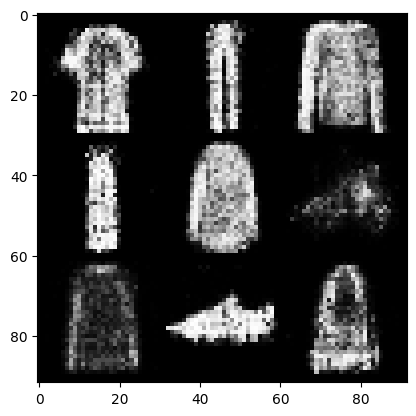

In [ ]:
num_epochs = 30

g_losses = []
d_losses = []


for epoch in range(1, num_epochs + 1):
  print(f'Epoch {epoch}/{num_epochs}')
  for i, (real_images, labels) in enumerate(tqdm(train_dataloader)):

    real_images, labels = real_images.to(device), labels.to(device)

    generator.train()

    batch_size = real_images.size(0)


    d_loss = discriminator_train_step(len(real_images), discriminator,
                                      generator, d_optimizer, criterion,
                                      real_images, labels, device)



    g_loss = generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion, device)


    g_losses.append(g_loss)
    d_losses.append(d_loss)

  generator.eval()
  print(f'g_loss: {g_loss}, d_loss: {d_loss}')
  z = torch.randn(9, 100).to(device)
  labels = torch.LongTensor(np.arange(9)).to(device)
  sample_images = generator(z, labels).unsqueeze(1).data.cpu()
  grid = make_grid(sample_images, nrow=3, normalize=True).permute(1,2,0).numpy()
  plt.imshow(grid)
  plt.show()

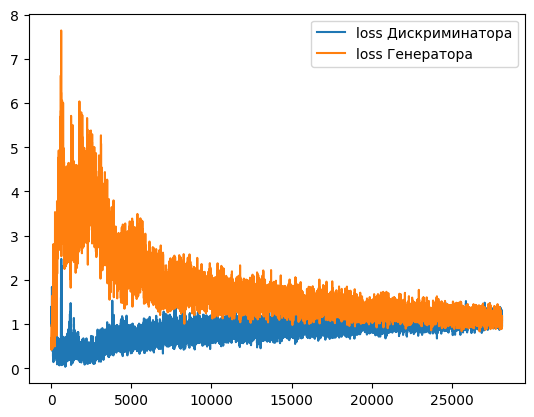

In [ ]:
plt.plot(d_losses, label='loss Дискриминатора')
plt.plot(g_losses, label='loss Генератора')

plt.legend()
plt.show()

In [ ]:
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")

#Оценка модели

Для начала взглянем на разные примеры сгенерованных изображений

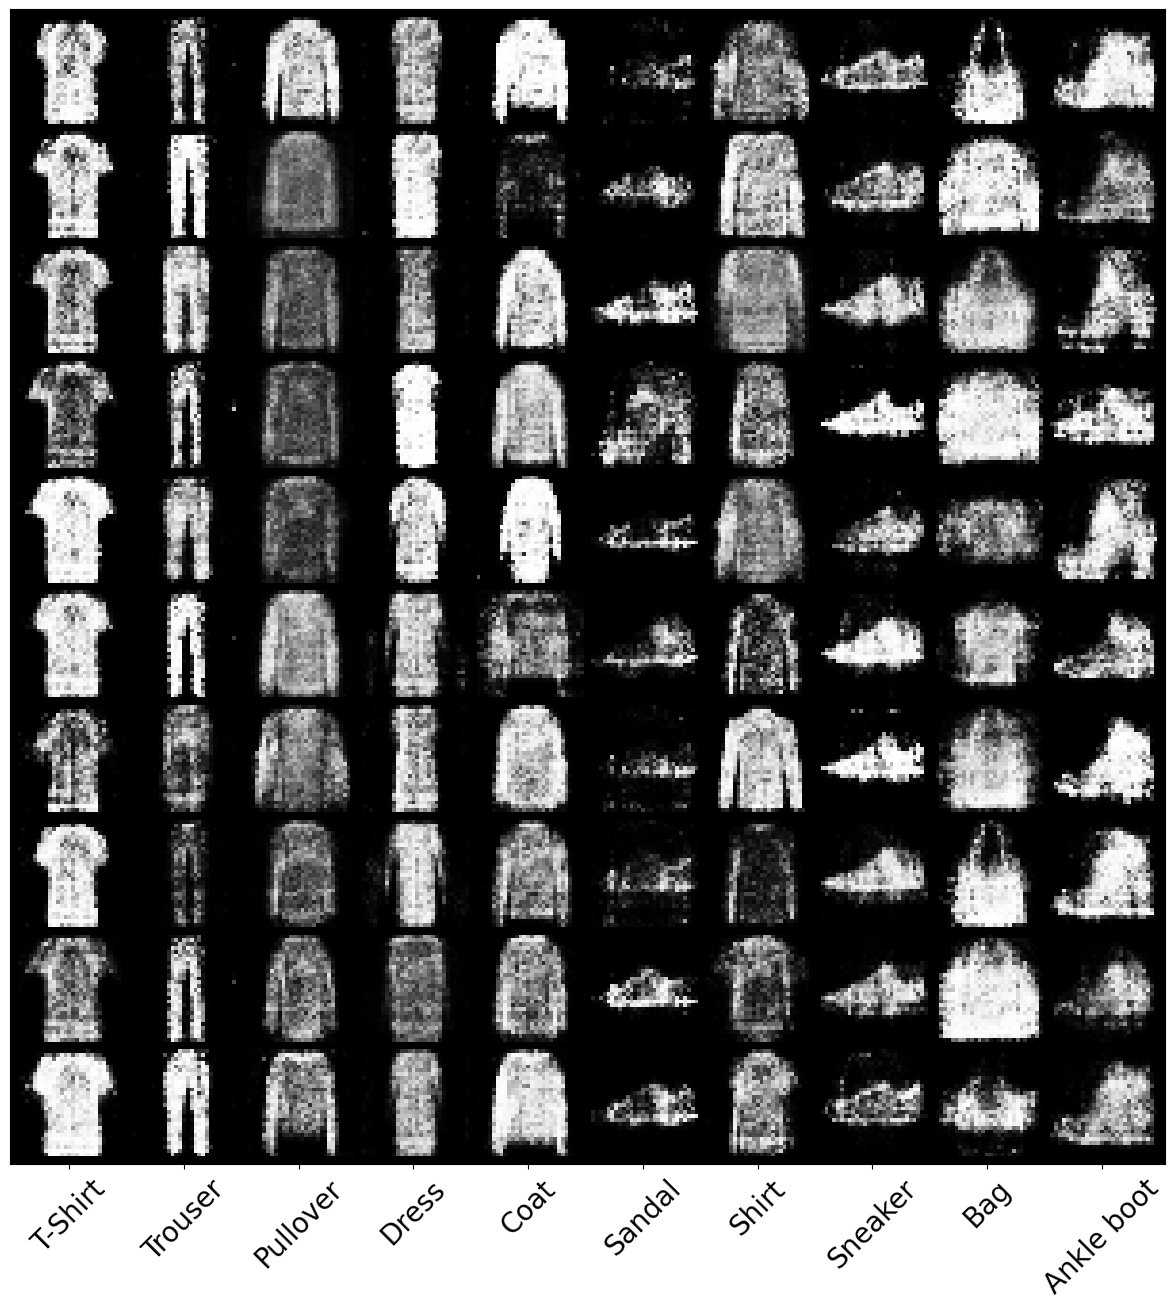

In [ ]:
z = torch.randn(100, 100).to(device)
labels = torch.LongTensor([i for _ in range(10) for i in range(10)]).to(device)
sample_images = generator(z, labels).unsqueeze(1).data.cpu()
grid = make_grid(sample_images, nrow=10, normalize=True).permute(1,2,0).numpy()
fig, ax = plt.subplots(figsize=(15,15))
ax.imshow(grid)
_ = plt.yticks([])
_ = plt.xticks(np.arange(15, 300, 30), ['T-Shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], rotation=45, fontsize=20)


Теперь проверим как себя ведет генератор при плавном изменении входа, а также удостоверимся, что модель не просто запоминает train dataset

Используем линейную интерполяцию, чтобы увидеть что происходит если плавно переходить между двумя точками

In [ ]:
def show_interp_samples(generator, point1, point2, n_interp=4, num_classes=10, device=device):
  n_total = n_interp + 2

  point1 = point1.reshape(-1).to(device)
  point2 = point2.reshape(-1).to(device)

  alphas = torch.linspace(0, 1, n_total, device=device)

  interpolated_z = torch.stack([
    (1 - alpha) * point1 + alpha * point2
    for alpha in alphas
  ])

  fig, axes = plt.subplots(
    num_classes,
    n_total,
    figsize=(1.8 * n_total, 1.8 * num_classes)
  )

  with torch.inference_mode():

    for label in range(num_classes):

      labels = torch.full((n_total,), label, dtype=torch.long, device=device)

      images = generator(interpolated_z, labels).cpu()

      images = (images + 1) / 2
      images = images.clamp(0, 1)

      for i in range(n_total):

        ax = axes[label, i]

        ax.imshow(images[i],cmap='gray')

        ax.axis('off')

        if i == 0:
          ax.set_ylabel(f'Class {label}', fontsize=12)

        if label == 0:
          ax.set_title(fr'${{\alpha}}={alphas[i]:.2f}$', fontsize=10)

  plt.tight_layout()
  plt.show()

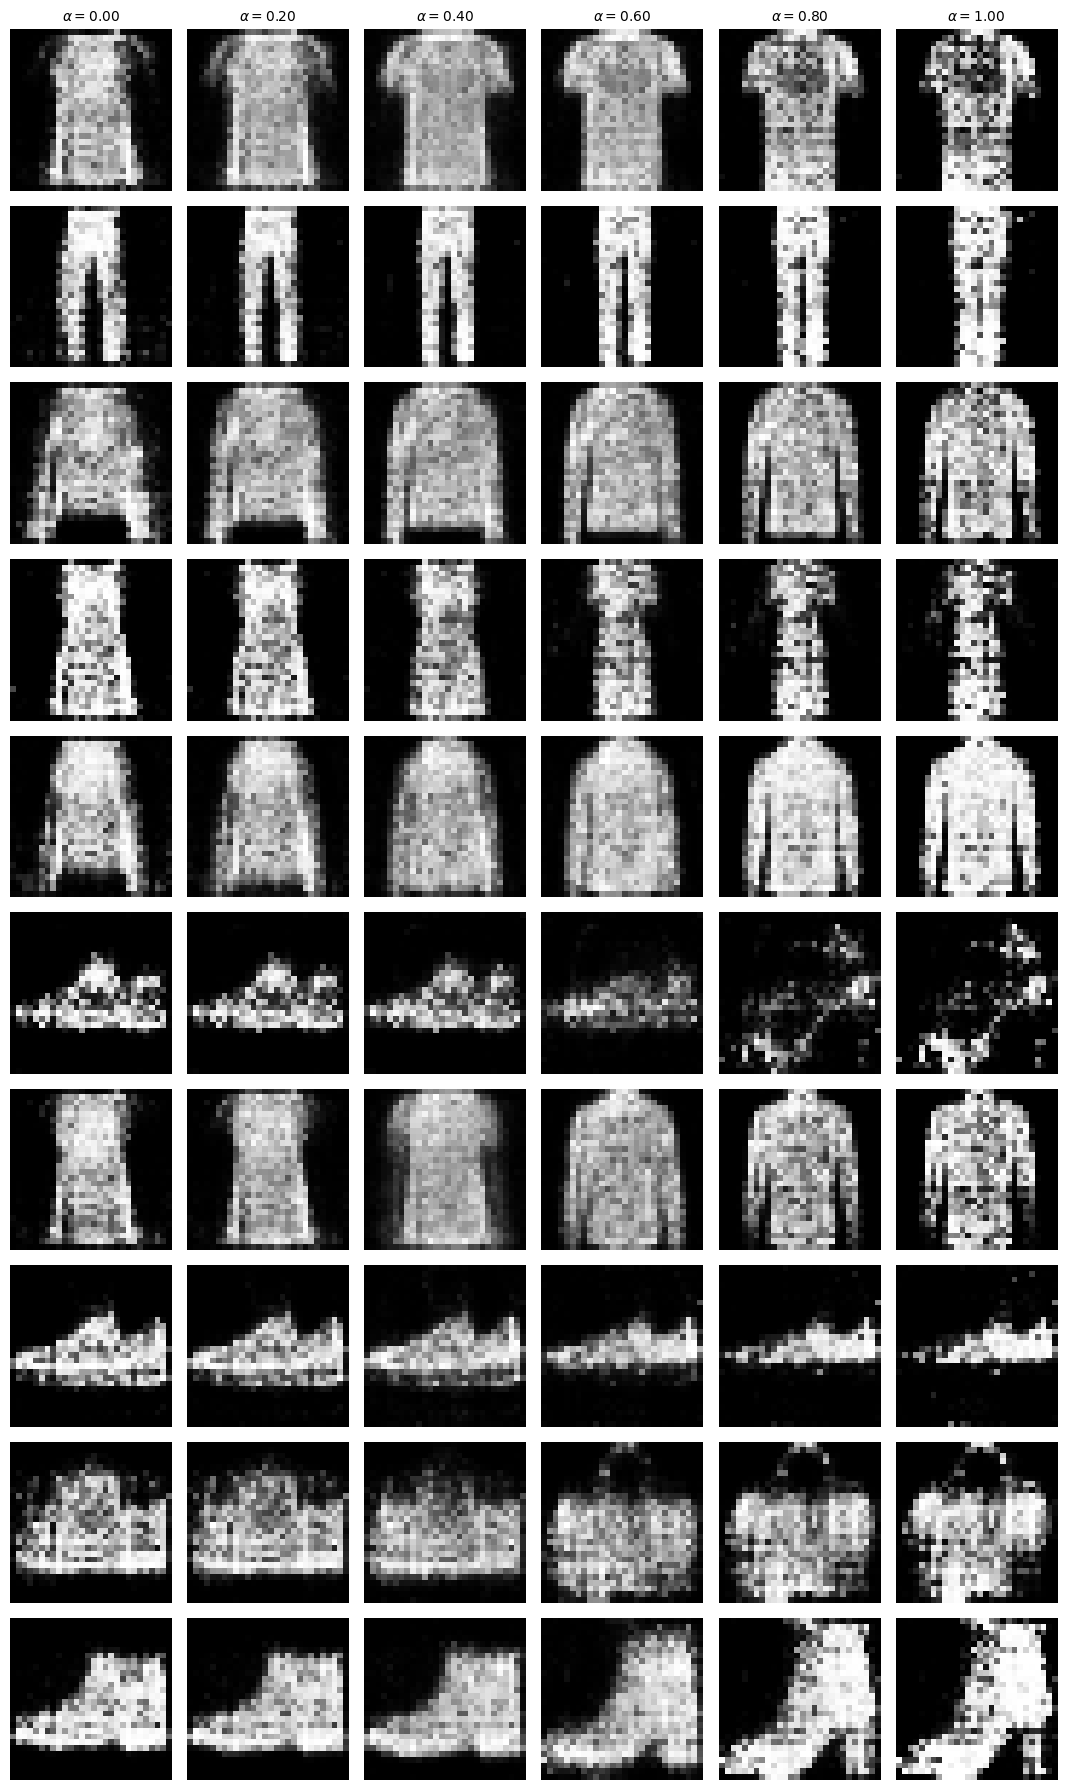

In [ ]:
noise_1 = torch.randn(100, device=device)

noise_2 = -noise_1

show_interp_samples(
  generator=generator,
  point1=noise_1,
  point2=noise_2,
  n_interp=4,
  num_classes=10,
  device=device
)

Теперь проверим не выдает ли нам генератор изображения из traing датасета (на самом деле уже видно, что по качеству изображения слегка уступают тем, которые находятся в X_train, однако реализованный интерфейс окажется полезен в будущем)

In [ ]:
def get_image(label, generator=generator, device=device):
  with torch.inference_mode():

    z = torch.randn(1, 100, device=device)

    labels = torch.tensor([label], dtype=torch.long, device=device)

    image = generator(z, labels)

  generator.train()

  image = image.squeeze(0).cpu()

  image = (image + 1) / 2
  image = image.clamp(0, 1)

  return image

In [ ]:
def find_closest_images(generated_image, target_label, X_train, y_train, n_closest=5):
  X_train_tensor = torch.as_tensor(X_train, dtype=torch.float32)

  y_train_tensor = torch.as_tensor(y_train)

  class_mask = y_train_tensor == target_label

  X_class = X_train_tensor[class_mask]

  X_class = X_class / 255.0

  generated_flat = generated_image.flatten()

  X_class_flat = X_class.reshape(X_class.shape[0], -1)

  distances = torch.norm(X_class_flat - generated_flat, p=2, dim=1)


  closest_distances, closest_indices = torch.topk(distances, k=n_closest, largest=False)

  closest_images = X_class[closest_indices]

  return (closest_images, closest_distances)

In [ ]:
def plot_generated_and_closest(generated_image, closest_images, distances, class_name):

  n_closest = len(closest_images)

  fig, axes = plt.subplots(1, n_closest + 1, figsize=(3 * (n_closest + 1), 4))

  axes[0].imshow(generated_image, cmap='gray')

  axes[0].set_title('Generated')

  axes[0].axis('off')

  for i in range(n_closest):

    axes[i + 1].imshow(closest_images[i], cmap='gray')

    axes[i + 1].set_title(f'Train {i+1}\n d={distances[i]:.2f}')

    axes[i + 1].axis('off')

  fig.suptitle(f'Class: {class_name}', fontsize=1)

  plt.tight_layout()
  plt.show()

In [ ]:
def closest_test(target_label, n_closest=5):
  generated_image = get_image(target_label)
  closest_images, distances = find_closest_images(generated_image, target_label, X_train, y_train, n_closest=n_closest)
  plot_generated_and_closest(generated_image, closest_images, distances, class_name=id_to_name[target_label])

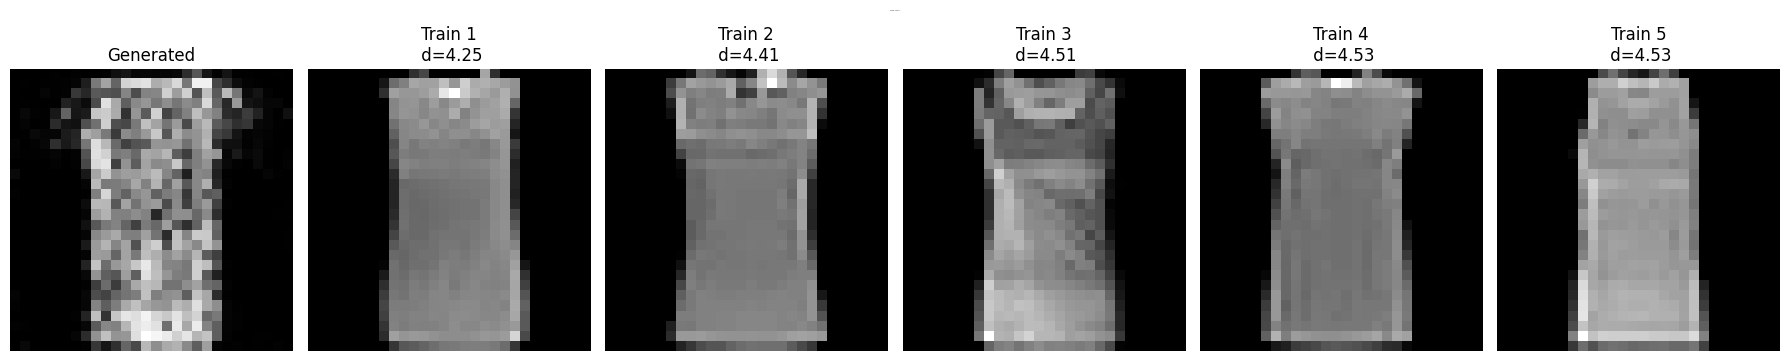

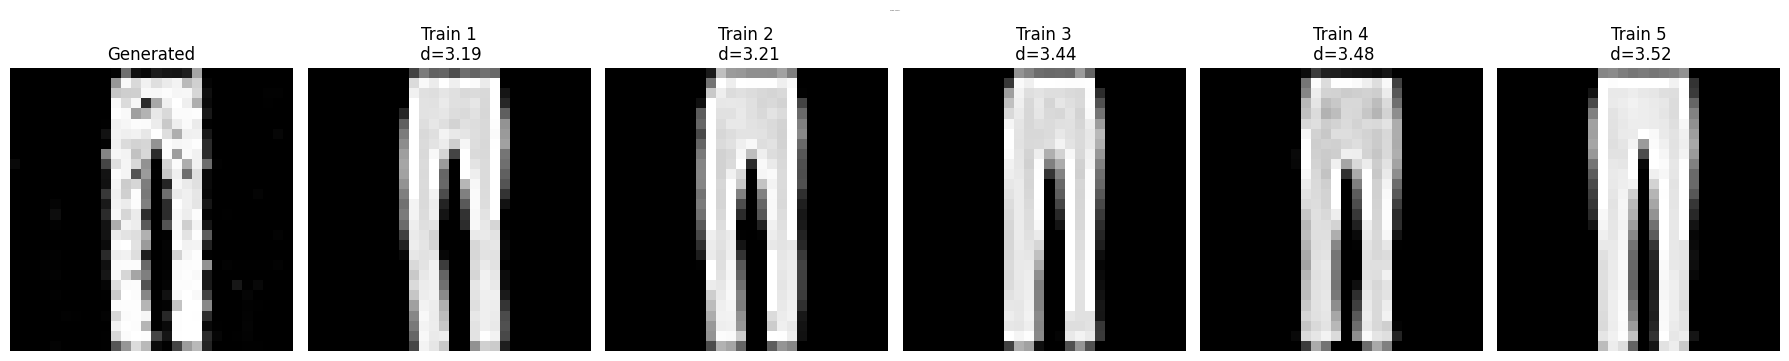

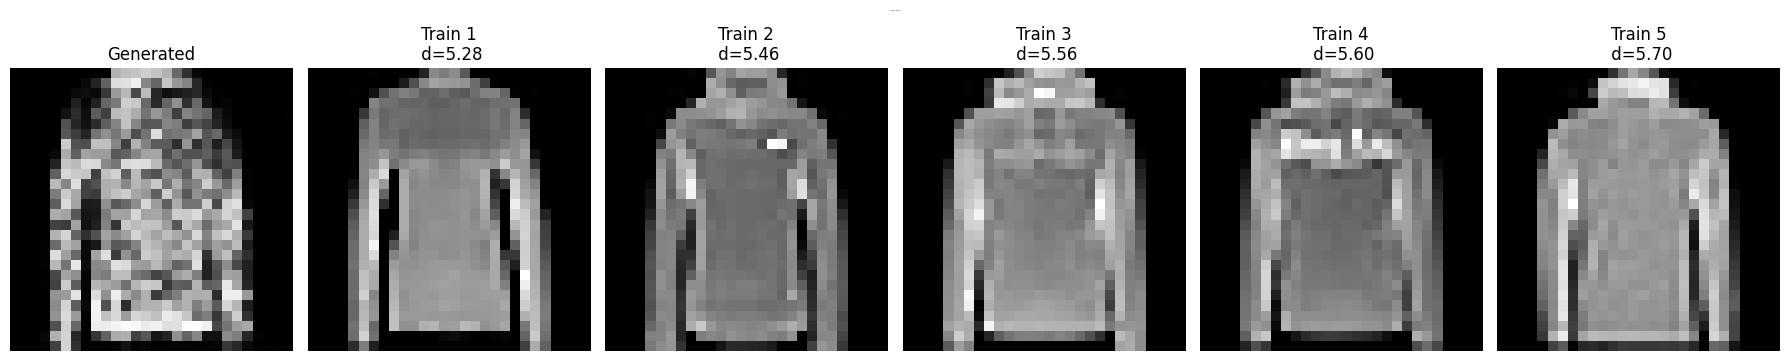

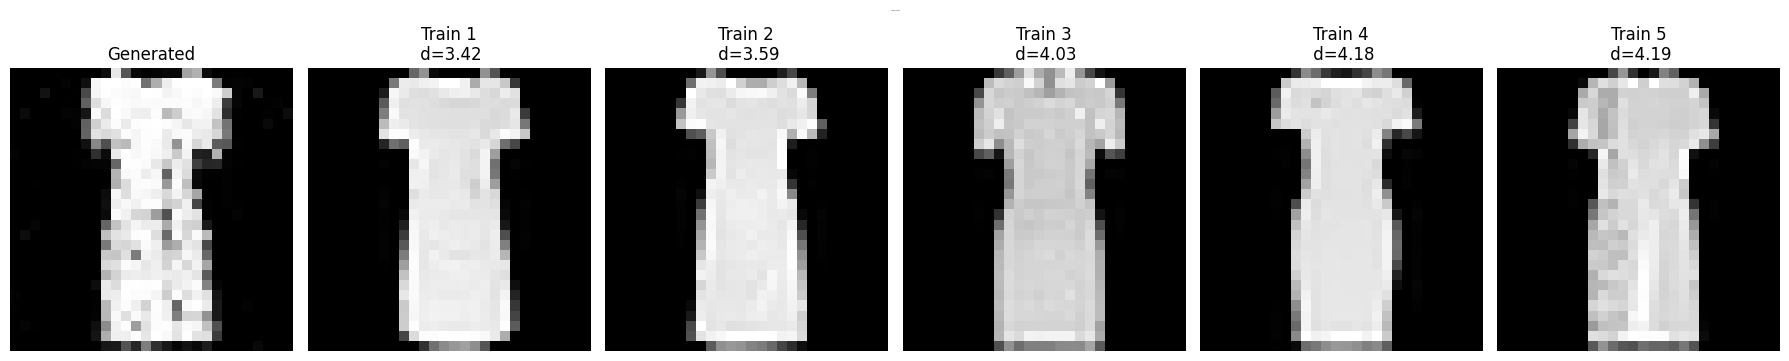

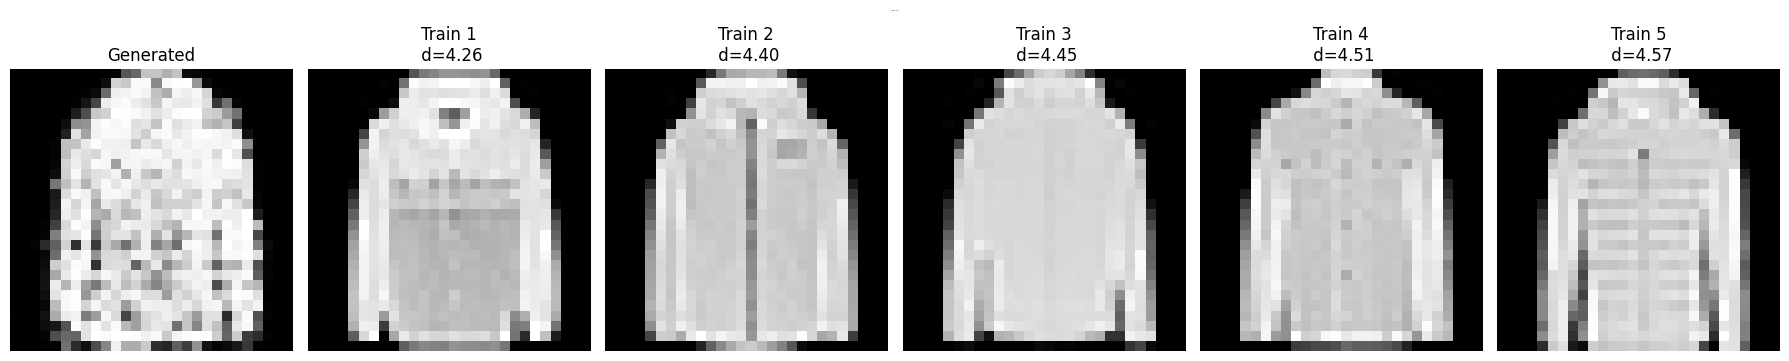

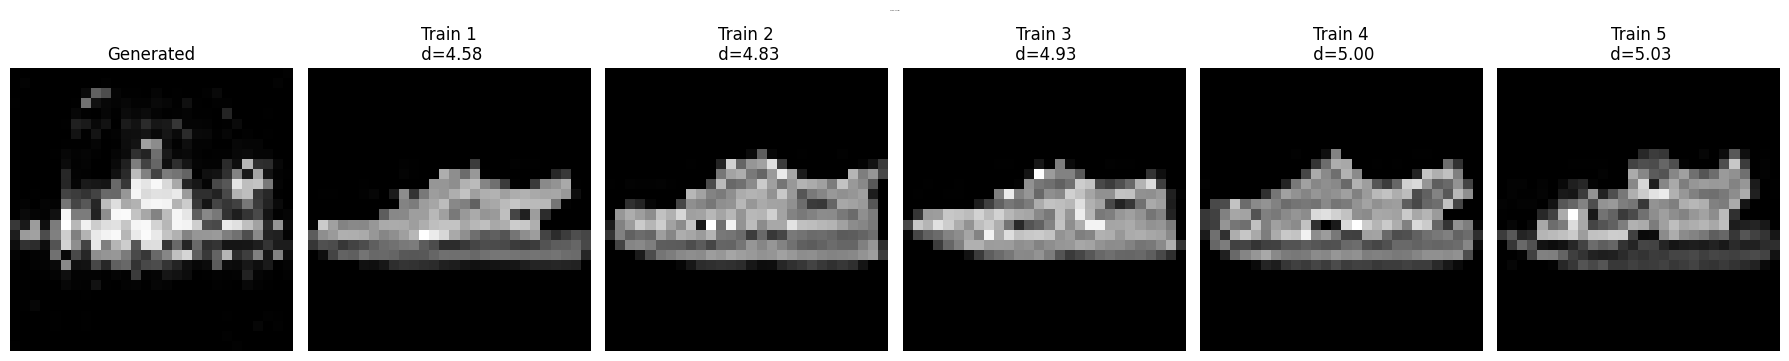

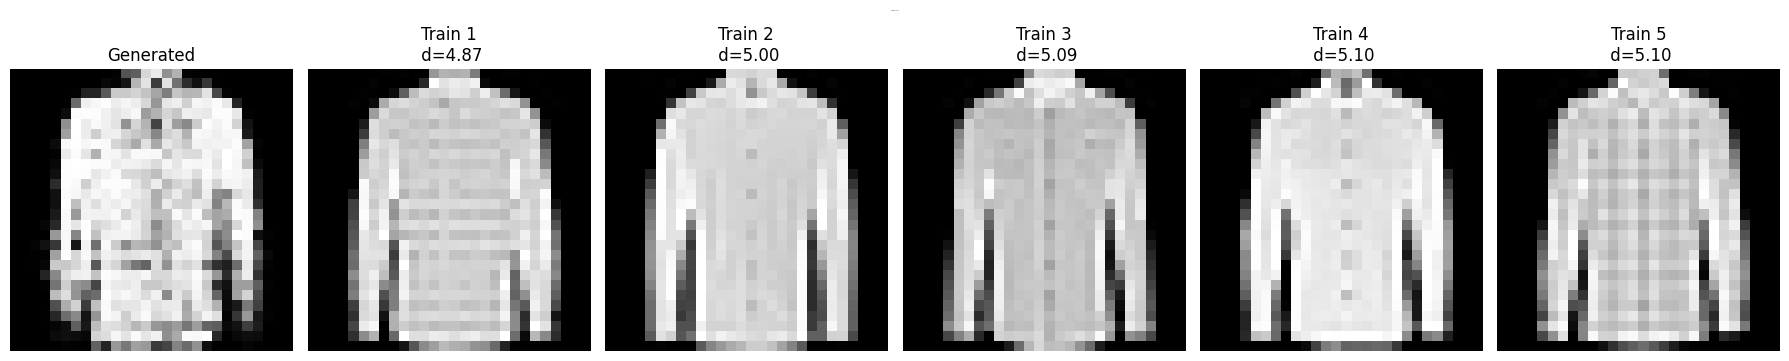

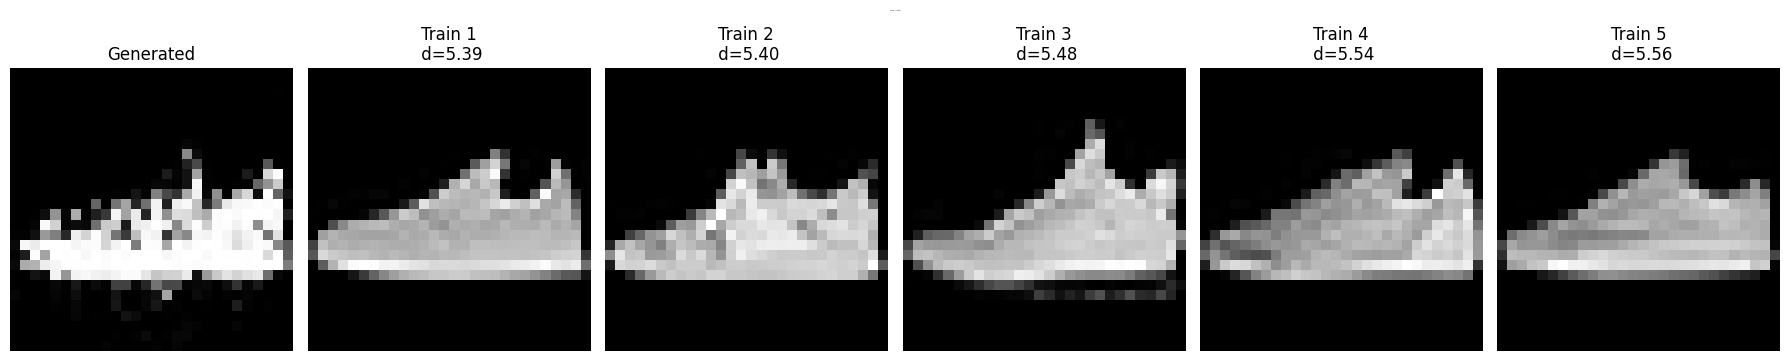

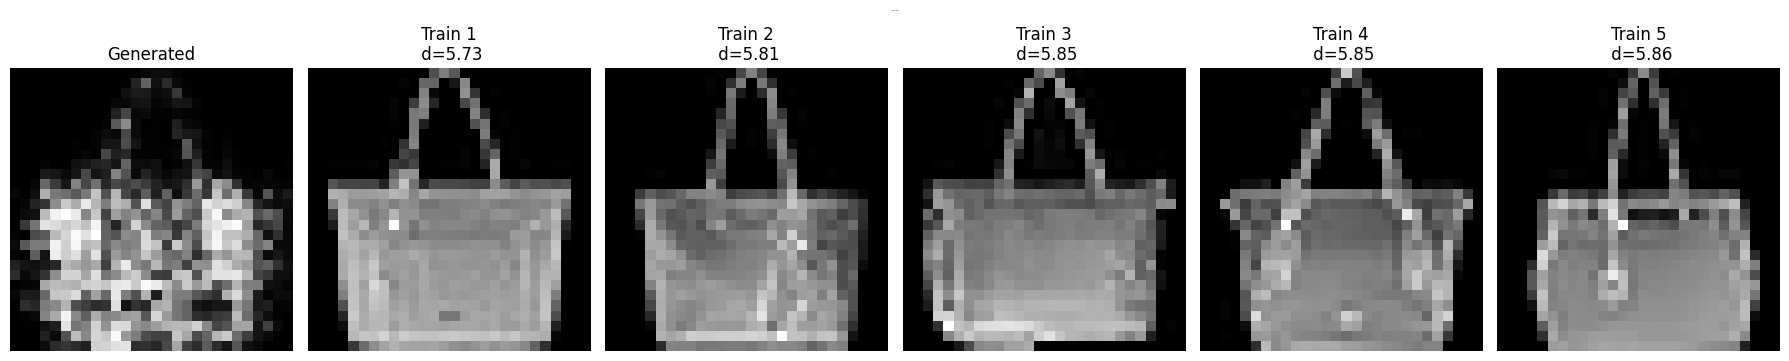

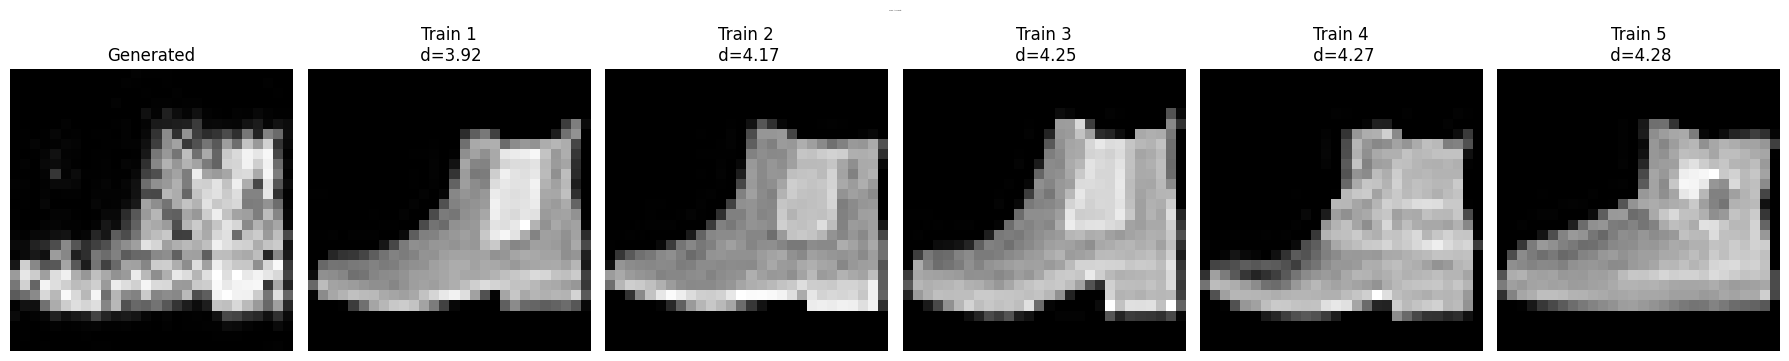

In [ ]:
for target_label in range(10):
  closest_test(target_label)

Как я и сказал сгенерованные изображения не идеальны, однако вполне узнаваемы.
Модель можно улучшить (чем мы и займемся ниже), однако в качестве baseline'а Simple C-GAN показал себя неплохо

Также ниже реализуем подсчет метрик FID и Diversity

In [ ]:
# TODO